# **ResNet18-Pruning-and-Compression-on-CIFAR10**

This notebook explores neural network pruning techniques for compressing a pretrained ResNet18 model on the CIFAR-10 image classification task. The goal is to study how different pruning strategies affect model accuracy, sparsity, computational cost, and retraining behavior.

The notebook is organized into five parts:

## 1. Model Evaluation

We first evaluate the baseline ResNet18 model by measuring:

- Test accuracy
- Parameter count
- MACs / computational cost
- Weight sparsity
- Weight distributions across layers

This gives a reference point for understanding how large and computationally expensive the original dense model is.

## 2. Magnitude Pruning

We implement unstructured magnitude pruning, where weights with the smallest absolute values are removed. This section includes:

- A reusable magnitude pruning function
- Layer-wise sensitivity analysis
- Adaptive per-layer sparsity selection
- Evaluation of accuracy after pruning

## 3. Regularization-Based Pruning

We explore how L1 and L2 regularization affect pruning behavior. The model is fine-tuned with regularization before pruning to study whether the weight distribution becomes more pruning-friendly.

This section compares:

- L1 regularization
- L2 regularization
- Accuracy changes after regularized pruning
- How regularization affects pruning robustness

## 4. Structured Pruning

We implement filter-wise structured pruning by removing entire convolutional filters based on their L1 norms. Unlike unstructured pruning, structured pruning is more hardware-friendly because it removes whole channels or filters rather than individual weights.

## 5. Iterative Pruning and Retraining

Finally, we implement a retraining pipeline for structured pruning. This includes:

- Generating masks for pruned filters
- Applying masks to weights and gradients
- Retraining the remaining parameters
- Recovering accuracy after pruning

Overall, this notebook demonstrates the trade-offs between compression, accuracy, and hardware efficiency in neural network pruning.

# GPU Requirement:

This notebook requires **CUDA support**. Please make sure to run it on a **local machine with a GPU** or on **Google Colab** with GPU enabled.

If you are working on Colab, click the 'Connect' button in the top-right corner. Once connected, go to Runtime->Change runtime type and select GPU as the hardware accelerator.

 Once you are connected to a GPU (either on local machine or Colab), you can run the following command to check the GPU on your machine.

In [ ]:
!nvidia-smi

Sun Feb 22 22:19:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P0             52W /  400W |    1726MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

# Initialization

In the following sections, we will import necessary packages, define model structure, and define some helper functions. Please make sure:


In [ ]:
! pip install thop

In [ ]:
import torch
import time
import math
import copy
import random
import logging
import requests
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from tqdm import tqdm
from torch.utils.data import DataLoader
from thop import profile
from thop import clever_format
from torchsummary import summary
from typing import Dict, Callable

assert torch.cuda.is_available()
logging.getLogger('thop').setLevel(logging.WARNING)

In [ ]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

ResNet Model (ResNet18, 34, 50, 101, 152)

## Model Define

In [ ]:
class BasicBlock(nn.Module):
    """
    BasicBlock is the fundamental building block of ResNet.
    It consists of two 3x3 convolutional layers.
    If the input dimensions do not match the output dimensions,
    or the stride is not 1, a shortcut (identity mapping) is used to adjust dimensions.
    """

    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        # First convolution layer with batch normalization
        self.conv1 = nn.Conv2d(
            in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(planes)

        # Second convolution layer with batch normalization
        self.conv2 = nn.Conv2d(
            planes, planes, kernel_size=3, stride=1, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(planes)

        # Shortcut connection (identity mapping)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion * planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_planes,
                    self.expansion * planes,
                    kernel_size=1,
                    stride=stride,
                    bias=False,
                ),
                nn.BatchNorm2d(self.expansion * planes),
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        shortcut_out = self.shortcut(x)
        out += shortcut_out
        out = F.relu(out)
        return out


class Bottleneck(nn.Module):
    """
    Bottleneck is the advanced building block used in deeper versions of ResNet (e.g., ResNet-50, ResNet-101).
    It consists of three layers: 1x1 conv, 3x3 conv, and another 1x1 conv.
    The purpose of the bottleneck is to reduce computation by compressing the dimensions before the 3x3 convolution.
    """

    expansion = 4

    def __init__(self, in_planes, planes, stride=1):
        super(Bottleneck, self).__init__()
        # 1x1 convolution to reduce the number of input channels
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)

        # 3x3 convolution for main processing
        self.conv2 = nn.Conv2d(
            planes, planes, kernel_size=3, stride=stride, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(planes)

        # 1x1 convolution to expand the number of output channels
        self.conv3 = nn.Conv2d(
            planes, self.expansion * planes, kernel_size=1, bias=False
        )
        self.bn3 = nn.BatchNorm2d(self.expansion * planes)

        # Shortcut connection
        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion * planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_planes,
                    self.expansion * planes,
                    kernel_size=1,
                    stride=stride,
                    bias=False,
                ),
                nn.BatchNorm2d(self.expansion * planes),
            )

    def forward(self, x):
        # Forward pass through the bottleneck block (1x1 -> 3x3 -> 1x1)
        out = F.relu(self.bn1(self.conv1(x)))
        out = F.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))

        # Add the shortcut connection and pass through ReLU again
        out += self.shortcut(x)
        out = F.relu(out)
        return out


class ResNet(nn.Module):
    """
    ResNet class that builds the full ResNet architecture using the BasicBlock or Bottleneck block.
    The number of blocks and layers is determined by the `num_blocks` parameter.
    """

    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet, self).__init__()
        self.in_planes = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)

        # Create the subsequent layers of the network using the blocks
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)

        # Final fully connected layer to classify the output
        self.linear = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, planes, num_blocks, stride):
        """
        Creates a residual layer consisting of `num_blocks` residual blocks.
        The first block may have a stride > 1 to downsample the feature maps.
        """
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_planes, planes, stride))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))

        # Pass through the 4 layers of the network
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = F.avg_pool2d(out, 4)

        # Flatten the output and pass through the fully connected layer
        out = out.view(out.size(0), -1)
        out = self.linear(out)
        return out


def ResNet18():
    return ResNet(BasicBlock, [2, 2, 2, 2])


def ResNet34():
    return ResNet(BasicBlock, [3, 4, 6, 3])


def ResNet50():
    return ResNet(Bottleneck, [3, 4, 6, 3])


def ResNet101():
    return ResNet(Bottleneck, [3, 4, 23, 3])


def ResNet152():
    return ResNet(Bottleneck, [3, 8, 36, 3])


In [ ]:
def train(model: nn.Module, train_dataloader: DataLoader, lr=0.1, epochs=10, device="cuda"):
    """
    Training function for training the model using the given dataloader, optimizer, and loss function.

    Args:
        model: The neural network model to be trained.
        train_dataloader: The DataLoader for the training data.
        lr: The learning rate for the optimizer.
        epochs: Number of epochs to train the model.
        device: Device to run the training on ('cuda' or 'cpu').

    Returns:
        None. Prints training progress for each epoch.
    """
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(
        model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs
    )

    for epoch in range(epochs):
        print(f"\nEpoch: {epoch+1}/{epochs}")
        model.train()
        train_loss = 0
        correct = 0
        total = 0

        with tqdm(total=len(train_dataloader), desc=f"Train Epoch {epoch+1}") as pbar:
            for batch_idx, (inputs, targets) in enumerate(train_dataloader):
                inputs, targets = inputs.to(device), targets.to(device)

                optimizer.zero_grad()
                outputs = model(inputs)

                # Compute the loss
                loss = criterion(outputs, targets)

                # Backward pass (backpropagation)
                loss.backward()

                # Optimizer step (update model parameters)
                optimizer.step()

                # Update the running loss and accuracy
                train_loss += loss.item()
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()

                pbar.set_postfix(
                    {
                        "Loss": f"{train_loss/(batch_idx+1):.3f}",
                        "Acc": f"{100.0 * correct / total:.3f}%",
                    }
                )
                pbar.update(1)
        scheduler.step()

        epoch_loss = train_loss / len(train_dataloader)
        epoch_acc = 100.0 * correct / total
        print(
            f"Epoch [{epoch+1}/{epochs}] - Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%"
        )


Download and model initialization function

In [ ]:
def download_and_load_model(url: str, weights_path: str, device="cuda"):
    """
    Downloads the model weights from the given URL and loads them into a ResNet18 model.

    Args:
        url (str): URL to download the model weights from.
        weights_path (str): Path to save the downloaded weights.
        device (str): Device to load the model onto ('cuda' or 'cpu').

    Returns:
        model (torch.nn.Module): The ResNet18 model with the loaded weights.
        recover_model (lambda): A lambda function to recover the model's state.
    """
    print(f"Downloading weights from {url}...")
    r = requests.get(url, allow_redirects=True)
    open(weights_path, 'wb').write(r.content)

    model = ResNet18()

    print(f"Loading weights from {weights_path}...")
    checkpoint = torch.load(weights_path, map_location=torch.device(device))

    if 'state_dict' in checkpoint:
        model.load_state_dict(checkpoint['state_dict'])
    else:
        model.load_state_dict(checkpoint)

    def recover_model():
        print("Recovering model to its original state.")
        if 'state_dict' in checkpoint:
            model.load_state_dict(checkpoint['state_dict'], strict = False)
        else:
            model.load_state_dict(checkpoint, strict=False)

    model = model.to(device)
    return model, recover_model

## Dataset

In [ ]:
class CIFAR:
    """
    Initialize CIFAR dataset (CIFAR-10 in this case).
    This class prepares the train and test data loaders.
    """

    def __init__(self, batch_size=128, num_workers=2):
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.train_loader, self.test_loader = self.prepare_data()

    def prepare_data(self):
        """
        Prepare train and test data loaders with transforms.
        """
        transform_train = transforms.Compose(
            [
                transforms.RandomCrop(32, padding=4),
                transforms.RandomHorizontalFlip(),
                transforms.ToTensor(),
                transforms.Normalize(
                    (0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)
                ),
            ]
        )

        transform_test = transforms.Compose(
            [
                transforms.ToTensor(),
                transforms.Normalize(
                    (0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)
                ),
            ]
        )

        trainset = torchvision.datasets.CIFAR10(
            root="./data", train=True, download=True, transform=transform_train
        )
        trainloader = torch.utils.data.DataLoader(
            trainset,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers,
        )

        testset = torchvision.datasets.CIFAR10(
            root="./data", train=False, download=True, transform=transform_test
        )
        testloader = torch.utils.data.DataLoader(
            testset, batch_size=128, shuffle=False, num_workers=self.num_workers
        )

        return trainloader, testloader

## Helper Function

In [ ]:
def test_magnitude_prune(
    test_tensor=torch.tensor([[0.15, -0.22, 0.75, -0.50, 0.60],
                              [-0.05, 0.82, -0.33, 0.19, -0.72],
                              [0.99, 0.03, -0.44, 0.85, -0.13],
                              [0.21, -0.11, 0.45, -0.78, 0.07],
                              [-0.29, 0.53, 0.89, -0.35, 0.46]]),
    test_mask=torch.tensor([[False, False, True, True, True],
                            [False, True, False, False, True],
                            [True, False, False, True, False],
                            [False, False, False, True, False],
                            [False, True, True, False, False]]),
    target_sparsity=0.6):

    def plot_matrix(tensor, ax, title):
        ax.imshow(tensor.cpu().numpy() == 0, vmin=0, vmax=1, cmap='summer')
        ax.set_title(title)
        ax.set_yticklabels([])
        ax.set_xticklabels([])
        for i in range(tensor.shape[1]):
            for j in range(tensor.shape[0]):
                text = ax.text(j, i, f'{tensor[i, j].item():.2f}', ha="center", va="center", color="k")

    # Clone the test tensor to avoid modifying the original
    test_tensor = test_tensor.clone()

    # Plot the original dense tensor
    fig, axes = plt.subplots(1, 2, figsize=(6, 10))
    ax_left, ax_right = axes.ravel()
    plot_matrix(test_tensor, ax_left, 'Dense Tensor')

    # Perform magnitude pruning
    pruned_tensor, mask = magnitude_pruning(test_tensor, target_sparsity)

    # Plot the pruned (sparse) tensor
    plot_matrix(pruned_tensor, ax_right, 'Sparse Tensor')
    fig.tight_layout()
    plt.show()

    # Print the results
    print('* Test magnitude_prune()')
    print(f'    Target sparsity: {target_sparsity:.2f}')
    print(f'    Sparsity of pruning mask: {mask.float().mean():.2f}')
    print(f'    Sparsity of pruned tensor: {(pruned_tensor == 0).float().mean():.2f}')
    if target_sparsity == 0.6:
      if test_mask.equal(mask):
          print('* Test passed.')
      else:
          print('* Test failed.')
    else:
      if (mask.float().mean() == 1 - target_sparsity):
          print('* Test passed.')
      else:
          print('* Test failed.')

In [ ]:
def test_loss_sensitive_magnitude_prune(
    test_tensor=torch.tensor([[0.15, -0.22, 0.75, -0.50, 0.60],
                              [-0.05, 0.82, -0.33, 0.19, -0.72],
                              [0.99, 0.03, -0.44, 0.85, -0.13],
                              [0.21, -0.11, 0.45, -0.78, 0.07],
                              [-0.29, 0.53, 0.89, -0.35, 0.46]]),
    test_grad=torch.tensor([[5.0,  0.01, 0.01,  0.01,  5.0],
                            [0.01, 0.01, 5.0,   5.0,   0.01],
                            [0.01, 5.0,  0.01,  0.01,  5.0],
                            [5.0,  0.01, 5.0,   0.01,  0.01],
                            [0.01, 5.0,  0.01,  5.0,   0.01]]),
    test_mask_06=torch.tensor([[ True, False, False, False,  True],
                              [False, False,  True,  True, False],
                              [False,  True, False, False,  True],
                              [ True, False,  True, False, False],
                              [False,  True, False,  True, False]]),
    test_mask_04=torch.tensor([[True, False, False, False, True],
                               [False, True, True, True, False],
                               [True, True, False, True, True],
                               [True, False, True, True, False],
                               [False, True, True, True, False]]),
    target_sparsity=0.6):

    def plot_matrix(tensor, ax, title):
        ax.imshow(tensor.cpu().numpy() == 0, vmin=0, vmax=1, cmap='summer')
        ax.set_title(title)
        ax.set_yticklabels([])
        ax.set_xticklabels([])
        for i in range(tensor.shape[1]):
            for j in range(tensor.shape[0]):
                text = ax.text(j, i, f'{tensor[i, j].item():.2f}', ha="center", va="center", color="k")

    # Clone the test tensor to avoid modifying the original
    test_tensor = test_tensor.clone()

    # Plot the original dense tensor
    fig, axes = plt.subplots(1, 2, figsize=(6, 10))
    ax_left, ax_right = axes.ravel()
    plot_matrix(test_tensor, ax_left, 'Dense Tensor')

    # Perform magnitude pruning
    pruned_tensor, mask = magnitude_pruning_gradient_based(test_tensor, test_grad, target_sparsity)

    # Plot the pruned (sparse) tensor
    plot_matrix(pruned_tensor, ax_right, 'Sparse Tensor')
    fig.tight_layout()
    plt.show()

    # Print the results
    print('* Test magnitude_prune()')
    print(f'    Target sparsity: {target_sparsity:.2f}')
    print(f'    Sparsity of pruning mask: {mask.float().mean():.2f}')
    print(f'    Sparsity of pruned tensor: {(pruned_tensor == 0).float().mean():.2f}')
    if target_sparsity == 0.6:
      if test_mask_06.equal(mask):
          print('* Test passed.')
      else:
          print('* Test failed.')
    elif target_sparsity == 0.4:
      if test_mask_04.equal(mask):
          print('* Test passed.')
      else:
          print('* Test failed.')
    else:
      if (mask.float().mean() == 1 - target_sparsity):
          print('* Test passed.')
      else:
          print('* Test failed.')

In [ ]:
def plot_layer_sensitivity(layer_accuracies_data, sparsities, baseline=93.79):
    """
    Plot the accuracy loss for different layer groups based on sparsity levels.

    Args:
        layer_accuracies_data (dict): A dictionary with layer names as keys and accuracy lists as values.
        baseline (float): The baseline accuracy of the unpruned model.
        sparsities (array-like): The sparsity levels applied for pruning.
    """
    layer_accuracies_loss = {}

    for layer in layer_accuracies_data:
        layer_accuracies_loss[layer] = [(acc - baseline) for acc in layer_accuracies_data[layer]]

    layer_groups = {
        'layer1': [i for i in layer_accuracies_loss.keys() if 'layer1' in i],
        'layer2': [i for i in layer_accuracies_loss.keys() if 'layer2' in i],
        'layer3': [i for i in layer_accuracies_loss.keys() if 'layer3' in i],
        'layer4': [i for i in layer_accuracies_loss.keys() if 'layer4' in i]
    }

    markers = ['o', 's', 'D', '^', 'v', '<', '>', 'p', '*', 'h', 'H', 'x', 'd']

    fig, axs = plt.subplots(2, 2, figsize=(12, 8))
    axs = axs.flatten()

    for i, (layer_group, layers) in enumerate(layer_groups.items()):
        ax = axs[i]
        for j, layer in enumerate(layers):
            marker = markers[j % len(markers)]
            ax.plot(sparsities, layer_accuracies_loss[layer], marker=marker, label=layer)

        ax.set_title(f'Layer Group: {layer_group}')
        ax.set_xlabel('Sparsity')
        ax.set_ylabel('Accuracy Loss')
        ax.legend()
        ax.grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_reg_model_accuracy_change(layer_accuracies_data_old, layer_accuracies_data_new, sparsities):
    layer_accuracies_diff = {}

    for layer in layer_accuracies_data_old:
        old_accs = layer_accuracies_data_old[layer]
        new_accs = layer_accuracies_data_new[layer]
        layer_accuracies_diff[layer] = [(new - old) for new, old in zip(new_accs, old_accs)]

    layer_groups = {
        'Layer1': sorted([i for i in layer_accuracies_diff.keys() if 'layer1' in i]),
        'Layer2': sorted([i for i in layer_accuracies_diff.keys() if 'layer2' in i]),
        'Layer3': sorted([i for i in layer_accuracies_diff.keys() if 'layer3' in i]),
        'Layer4': sorted([i for i in layer_accuracies_diff.keys() if 'layer4' in i])
    }

    plt.style.use('default')
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))
    axs = axs.flatten()

    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57', '#FF9FF3', '#54A0FF', '#5F27CD']

    for i, (layer_group, layers) in enumerate(layer_groups.items()):
        ax = axs[i]

        if not layers:
            ax.text(0.5, 0.5, f'No {layer_group} layers found',
                   ha='center', va='center', transform=ax.transAxes, fontsize=14)
            ax.set_title(f'{layer_group}', fontsize=16, fontweight='bold', pad=20)
            continue

        n_sparsities = len(sparsities)
        n_layers = len(layers)
        bar_width = 0.15
        x_positions = np.arange(n_sparsities)

        for j, layer in enumerate(layers):
            offset = (j - (n_layers - 1) / 2) * bar_width
            diff_values = layer_accuracies_diff[layer]

            bars = ax.bar(x_positions + offset, diff_values, bar_width,
                         label=layer, alpha=0.8, color=colors[j % len(colors)],
                         edgecolor='white', linewidth=0.5)

        ax.set_title(f'{layer_group} - Accuracy Difference', fontsize=14, fontweight='bold', pad=15)
        ax.set_xlabel('Sparsity Level', fontsize=12)
        ax.set_ylabel('Accuracy Difference (%)', fontsize=12)

        ax.set_xticks(x_positions)
        ax.set_xticklabels([f'{s:.1f}' for s in sparsities], fontsize=10)

        ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9,
                 frameon=True, fancybox=True, shadow=True)

        ax.grid(True, alpha=0.3, linestyle='--')
        ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5, alpha=0.8)

        if layers:
            y_min = min([min(layer_accuracies_diff[layer]) for layer in layers])
            y_max = max([max(layer_accuracies_diff[layer]) for layer in layers])
            margin = (y_max - y_min) * 0.1 if y_max != y_min else 0.1
            ax.set_ylim(y_min - margin, y_max + margin)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

## Load Model and Dataset

In [ ]:
url = "https://github.com/shawnyin128/25Fall-CSCI-GA-3033-EfficientAI-Materials/blob/master/model/best_model.pth?raw=true"
weights_path = "./best_model.pth"

model, recover_model = download_and_load_model(url, weights_path, device="cuda")

Loading weights from ./best_model.pth...


In [ ]:
dataloader = {}
dataloader['train'], dataloader['test'] = CIFAR().train_loader, CIFAR().test_loader

# Module 1: Model Evaluation

**Context & Motivation:**

Model metrics are essential for providing an objective standard to evaluate success and guide our optimization. In this lab, our analysis focuses on the trade-off between two key dimensions: Performance and Efficiency.

**Methods & Concepts:**

For Performance, since we are performing classification with ResNet, Accuracy is the most direct metric to assess the model's predictive capability. For Efficiency, we use Parameter Count and MACs (Multiply-Accumulate Operations) to directly measure the model's size and computational workload. Furthermore, as we apply pruning, we will use Sparsity to quantify the proportion of redundant weights successfully removed.


In [ ]:
def evaluate(model: nn.Module, test_dataloader: DataLoader, device="cuda") -> float:
    """
    Inference function to evaluate the model on a test dataset using the provided dataloader,
    with tqdm progress bar for visualization.

    Args:
        model: The neural network model to be used for inference.
        test_dataloader: The dataloader for the test data.
        device: Device to use ('cuda' or 'cpu').

    Returns:
        None: Prints the accuracy on the test set.
    """
    model = model.to(device)
    model.eval()

    correct = 0
    total = 0

    # Disable gradient computation during inference
    with torch.no_grad():
        for inputs, targets in tqdm(test_dataloader, desc="Evaluating", leave=False):
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)

            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
            
    accuracy = 100.0 * correct / total
    # print(f"Accuracy on the test set: {accuracy:.2f}%")
    return accuracy

In [ ]:
def calculate_sparsity(model: nn.Module) -> float:
    """
    Calculate the sparsity of a given model (proportion of zero weights).

    Args:
        model (nn.Module): The PyTorch model to calculate sparsity for.

    Returns:
        float: The sparsity of the model (proportion of zero weights).
    """
    total_params = 0
    zero_params = 0

    # Iterate over each parameter tensor in the model
    for param in model.parameters():
        total_params += param.numel()
        zero_params += (param == 0).sum().item()

    sparsity = zero_params / total_params
    return sparsity

In [ ]:
def calculate_MACs_and_Params_by_thop(model: nn.Module, input_size: tuple = (1, 3, 32, 32)) -> float:
    """
    Calculate the MACs (Multiply-Accumulate) of a model.

    Args:
        model (nn.Module): The PyTorch model to calculate MACs for.
        input_size (tuple): The size of the input tensor, e.g., (1, 3, 32, 32) for CIFAR-10.

    """
    # Create a dummy input with the correct input size
    dummy_input = torch.randn(*input_size).cuda()

    # Use thop to profile the model and calculate FLOPs
    macs, params = profile(model, inputs=(dummy_input,))
    macs, params = clever_format([macs, params], "%.3f")

    return macs, params

Next, run the following cell to evaluate the original model.


In [ ]:
accuracy = evaluate(model, dataloader['test'])
sparsity = calculate_sparsity(model)
macs, params = calculate_MACs_and_Params_by_thop(model)
print(f'Accuracy: {accuracy}%, MACs: {macs}, Params: {params}, Sparsity: {sparsity}%')

[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.Conv2d'>.
[INFO] Register count_normalization() for <class 'torch.nn.modules.batchnorm.BatchNorm2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.container.Sequential'>.
[INFO] Register count_linear() for <class 'torch.nn.modules.linear.Linear'>.
Accuracy: 93.79%, MACs: 557.880M, Params: 11.174M, Sparsity: 0.0%


From the evaluation results, our model achieve a ~93% accuracy in the CIFAR-10 test dataset. However, for a relatively simple task CIFAR-10 classification, this model is arguably larger than necessary. Reducing the model's size without sacrificing much accuracy could improve its efficiency, making it more suitable for deployment on resource-constrained devices like mobile phones or embedded systems.



In the upcoming steps of this lab, we will apply pruning techniques to reduce the size of the model, making it more computationally efficient. By pruning away less important weights, we aim to:


*   **Increase sparsity:** Introduce zero weights, reducing the total number of parameters.
*   **Reduce MACs:** Lower the computational cost for forward passes, making the model faster.
*   **Maintain performance:**: Keep the accuracy as high as possible, while shrinking the model's size.






## Weight Distribution of ResNet18 

**Context & Motivation:**

Before we proceed to pruning, we must understand the numerical "landscape" of the original model. In the context of model compression, weight values are not just random numbers; they represent the model's learned knowledge. Investigating the distribution of these weights is a fundamental step, as it allows us to visually and statistically identify redundancy—specifically, the concentration of weights near zero that contribute little to the model's final output.

**Methods & Concepts:**

By analyzing the weight distribution (typically via histograms), we can determine a meaningful pruning threshold. This distribution directly informs our pruning strategy.

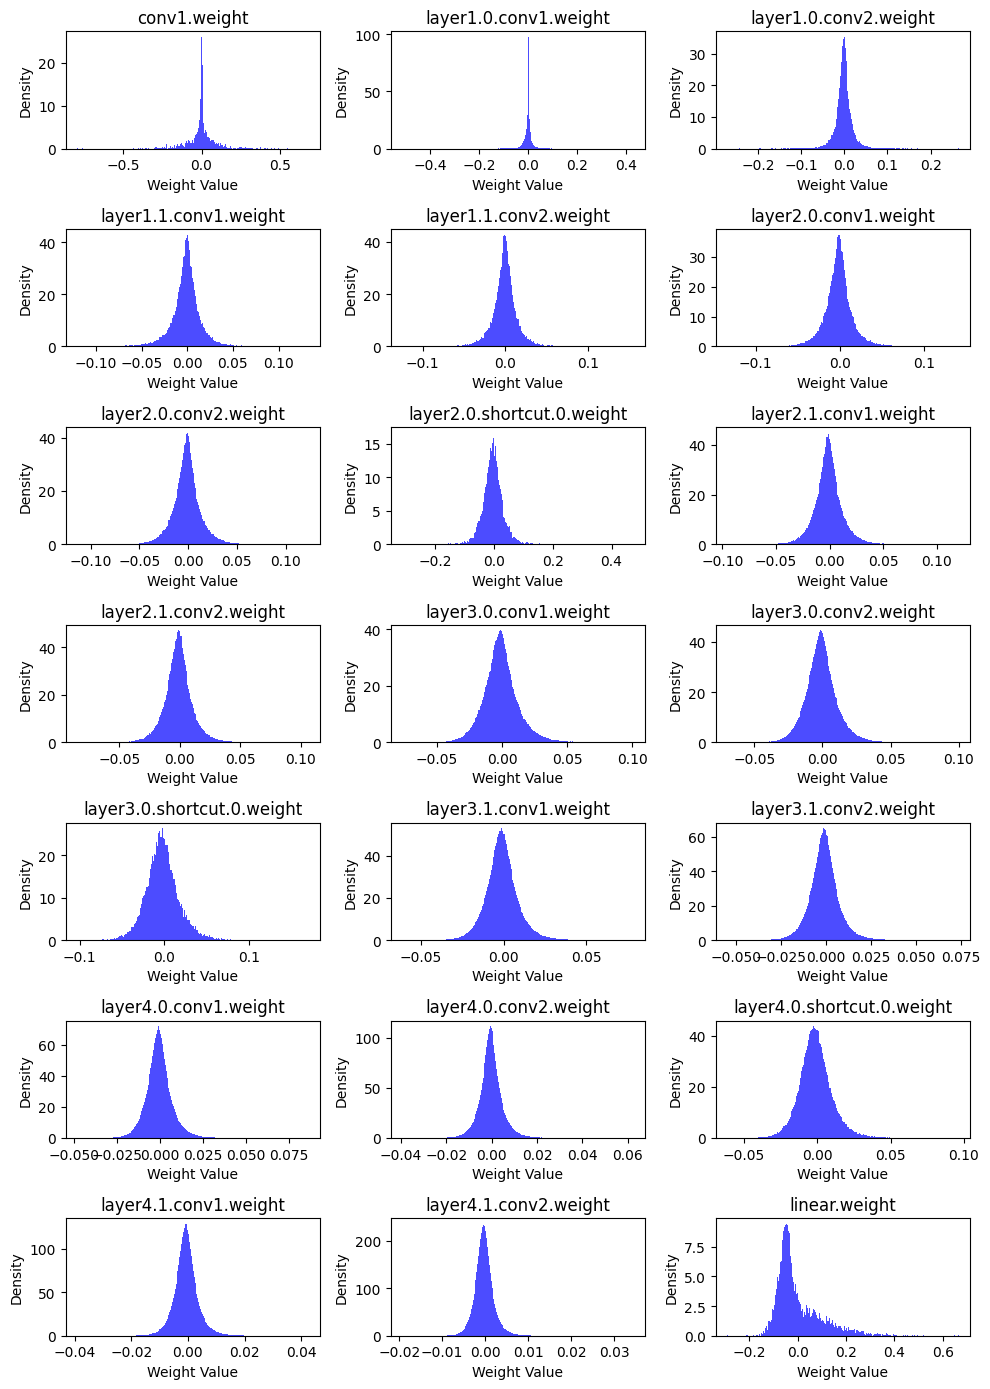

In [ ]:
def visualize_weight_distribution(model, bins=256, exclude_zero=False):
    weight_data = [] # Collect weights to be visulized
    layer_names = []

    for layer_name, param_tensor in model.named_parameters():
        if param_tensor.dim() > 1:  # Only consider weight tensors, ignore biases and batch norm
            param_data = param_tensor.detach().cpu().numpy().flatten()
            weight_data.append(param_data)
            layer_names.append(layer_name)  # Collect layer names

    num_layers = len(weight_data)
    columns = 3
    rows = math.ceil(num_layers / columns)

    fig, axes = plt.subplots(rows, columns, figsize=(10, rows * 2))
    axes = axes.flatten()

    for i, (layer_weights, layer_name) in enumerate(zip(weight_data, layer_names)):
        ax = axes[i]
        if exclude_zero:
            layer_weights = layer_weights[layer_weights != 0]
        ax.hist(layer_weights, bins=bins, density=True, color='blue', alpha=0.7)
        ax.set_title(layer_name)
        ax.set_xlabel('Weight Value')
        ax.set_ylabel('Density')

    for j in range(num_layers, len(axes)):
        fig.delaxes(axes[j])
    fig.tight_layout()
    plt.show()

visualize_weight_distribution(model)

## Weight Distribution Analysis

**What common characteristics do you observe in the weight distributions across different layers? Can these characteristics make the pruning more efficient or difficult? Explain your reasoning.**


**Answer:**

- In all the weight distributions across different layers we see a spike around 0 and the weights are roughly symmetric about zero. This means that most of the weight values are concentrated around 0, which means there could be a lot of weights that contribute little to the model's final output. These characteristics make magnitude pruning more efficient because the huge mass of weights near zero are natural candidates to remove with little impact on the model's performance.


- Another interesting characteristic is that in a few of the earlier layers, we observe the weight distributions have wider tails, i.e., they have more large-magnitude weights. For example, the weight values of "conv1.weight" approximately fall in the range [-0.6, 0.6], "layer1.0.conv2.weight" approximately fall in the range [-0.3, 0.3], "layer2.0.shortcut.0.weight" approximately falls between [-0.2, 0.2]. Additionally, the weight values of "linear.weight" approximately fall in the range [-0.3, 0.7]. In the deeper layers, the weight values seem to be comparatively smaller, i.e., the weight distributions are tighter. For example, "layer4.0.conv1.weight" has weight values approximately between [-0.025, 0.025], "layer4.1.conv2.weight" falls approximately between [-0.01, 0.01]. This makes magnitude pruning difficult because if you use one global threshold, the same cutoff can over-prune tight-scale layers while under-prune others because different layers have different spreads/scales as can be seen in the distributions. To show this, assume layer A has weights mostly in [-0.02, 0.02], and layer B has weights mostly in [-0.2, 0.2]. If we prune weights with |w|< θ and choose θ = 0.01, you might prune a huge fraction of the weights of layer A, maybe even the important weights. But for layer B, θ = 0.01 may prune comparatively much fewer weights due to its wider spread.

- Therefore, if the method of pruning used is magnitude pruning, the more optimal strategy is to use layer-wise sparsity so that we don't force the same threshold on layers that have completely different spread/scales.

# Module 2: Magnitude Pruning

Magnitude pruning is a commonly used technique to reduce the size and complexity of DNNs while maintaining good performance. It involves removing weights with smaller magnitudes because these weights contribute less to the output of the model.

By removing these less significant weights, we can reduce the computational and memory requirements of the model without heavily impacting its accuracy.

<p align="center">
  <img src="https://github.com/shawnyin128/25Fall-CSCI-GA-3033-EfficientAI-Materials/raw/master/graph/magnitude_pruning.png" alt="Magnitude Pruning" width="400"/>
</p>



In this module, you will learn how to implement magnitude pruning to reduce the size and complexity of a neural network while maintaining performance. Additionally, you will explore the sensitivity of each layer to pruning, and finally, you'll have the opportunity to experiment with your own pruning strategy.

## Magnitude Pruning Implementation


**Context & Motivation:**

The pruning of an entire neural network is inherently composed of the pruning of its individual weight matrices. Consequently, a single weight tensor represents the smallest unit of the pruning process. By first implementing the pruning logic for a single weight and creating a reusable function, we can efficiently scale the process to handle the complex, multi-layered architecture of the entire model.

**Methods & Concepts:**

We will adopt the simplified magnitude pruning as our core strategy for each weight parameter. The algorithm can be found in this algorithm block.

<p align="center">
  <img src="https://github.com/shawnyin128/25Fall-CSCI-GA-3033-EfficientAI-Materials/raw/master/graph/algo_magnitude.png" alt="Magnitude Pruning Algorithm" width="400"/>
</p>

In [ ]:
def magnitude_pruning(tensor: torch.Tensor, sparsity: float) -> torch.Tensor:
    """
    Apply magnitude pruning to a given tensor.

    Args:
        tensor (torch.Tensor): The input tensor to be pruned.
        sparsity (float): The desired spars
    Returns:
        pruned_tensor (torch.Tensor): The pruned tensor.
        mask (torch.Tensor): The pruning mask (where True means the weight is kept, and False means it is pruned).
    """
    sparsity = min(max(0.0, sparsity), 1.0)
    pruned_tensor = tensor.clone()
    mask = torch.zeros_like(tensor, dtype=torch.bool)
    
    #1. flatten the tensor
    flattened_tensor = tensor.view(-1)

    #2. calculate the pruning threshold
    threshold = torch.quantile(flattened_tensor.abs(), sparsity)

    #3. create a mask
    mask = (tensor.abs() >= threshold)

    #4. create the pruned tensor
    pruned_tensor = tensor * mask

    mask = mask.to(tensor.device)
    pruned_tensor = pruned_tensor.to(tensor.device)

    return pruned_tensor, mask

We validate the correctness of our magnitude pruning function by applying it to a dummy tensor.

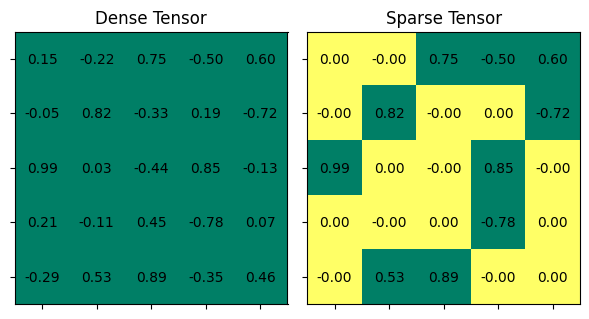

* Test magnitude_prune()
    Target sparsity: 0.60
    Sparsity of pruning mask: 0.40
    Sparsity of pruned tensor: 0.60
* Test passed.


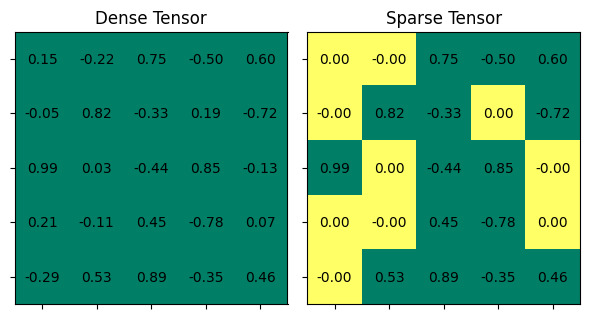

* Test magnitude_prune()
    Target sparsity: 0.40
    Sparsity of pruning mask: 0.60
    Sparsity of pruned tensor: 0.40
* Test passed.


In [ ]:
test_magnitude_prune(target_sparsity=0.6)
test_magnitude_prune(target_sparsity=0.4)

## Model Pruning and Sensitivity Analysis

**Context & Motivation:**

As discussed earlier, pruning an entire model is equivalent to pruning every individual weight within it. However, our previous weight distribution analysis revealed that each weight matrix possesses a unique numerical distribution. Because of these differences, each layer exhibits a different level of sensitivity to sparsity. To achieve the best overall compression, each layer should ideally operate at its own optimal sparsity level.

**Methods & Concepts:**

To determine these per-layer levels, we will use a grid search approach. By systematically varying the sparsity of each individual layer while keeping others constant, we can observe the tolerance pattern of each layer.

In [ ]:
@torch.no_grad()
def sensitivity_scan_per_layer(model: nn.Module, dataloader: torch.utils.data.DataLoader,
                               start: float, step: float, end: float,
                               device: str = 'cuda', verbose=True):
    """
    Perform a sensitivity scan by applying magnitude pruning to each individual layer of the model
    and evaluate the accuracy at different levels of sparsity for each layer.

    Args:
        model (nn.Module): The neural network model to be pruned and evaluated.
        dataloader (DataLoader): DataLoader for the test dataset.
        start (float): Starting sparsity level.
        step (float): Step size for increasing sparsity.
        end (float): Ending sparsity level.
        device (str): Device to use ('cuda' or 'cpu').
        verbose (bool): Whether to print progress and results.

    Returns:
        dict: Dictionary containing sparsity levels and corresponding accuracies for each layer.
    """
    sparsities = np.arange(start, end, step)

    layer_accuracies = {}

    model.to(device)

    for name, param in model.named_parameters():
        if param.dim() > 1 and 'layer' in name:
            print(f"\nScanning layer: {name}")
            param_clone = param.detach().clone()

            accuracy_per_layer = []
            for sparsity in sparsities:
                pruned_tensor, mask = magnitude_pruning(param, sparsity)
                param.data.copy_(pruned_tensor)
                accuracy = evaluate(model, dataloader, device=device)
                accuracy_per_layer.append(accuracy)

                if verbose:
                    print(f"Sparsity: {sparsity:.2f} | Accuracy: {accuracy:.2f}%")

                param.data.copy_(param_clone)

            layer_accuracies[name] = accuracy_per_layer
    return sparsities, layer_accuracies

In [ ]:
recover_model()
sparsities, layer_accuracies = sensitivity_scan_per_layer(model, dataloader['test'], 0.4, 0.1, 1.0)

Recovering model to its original state.

Scanning layer: layer1.0.conv1.weight


Sparsity: 0.40 | Accuracy: 93.80%


Sparsity: 0.50 | Accuracy: 93.79%


Sparsity: 0.60 | Accuracy: 93.77%


Sparsity: 0.70 | Accuracy: 93.60%


...

Sparsity: 0.50 | Accuracy: 93.74%


Sparsity: 0.60 | Accuracy: 93.70%


Sparsity: 0.70 | Accuracy: 93.55%


Sparsity: 0.80 | Accuracy: 93.43%


Sparsity: 0.90 | Accuracy: 92.73%


The visualization function referenced below will allow you to see how the accuracy of the model is affected as we increase the sparsity in different layers.

This plot will clearly show you the impact of pruning on different layers, and how the accuracy degrades as more weights are pruned. So sit back, run the visualization function below, and take a closer look at the results of your hard work!


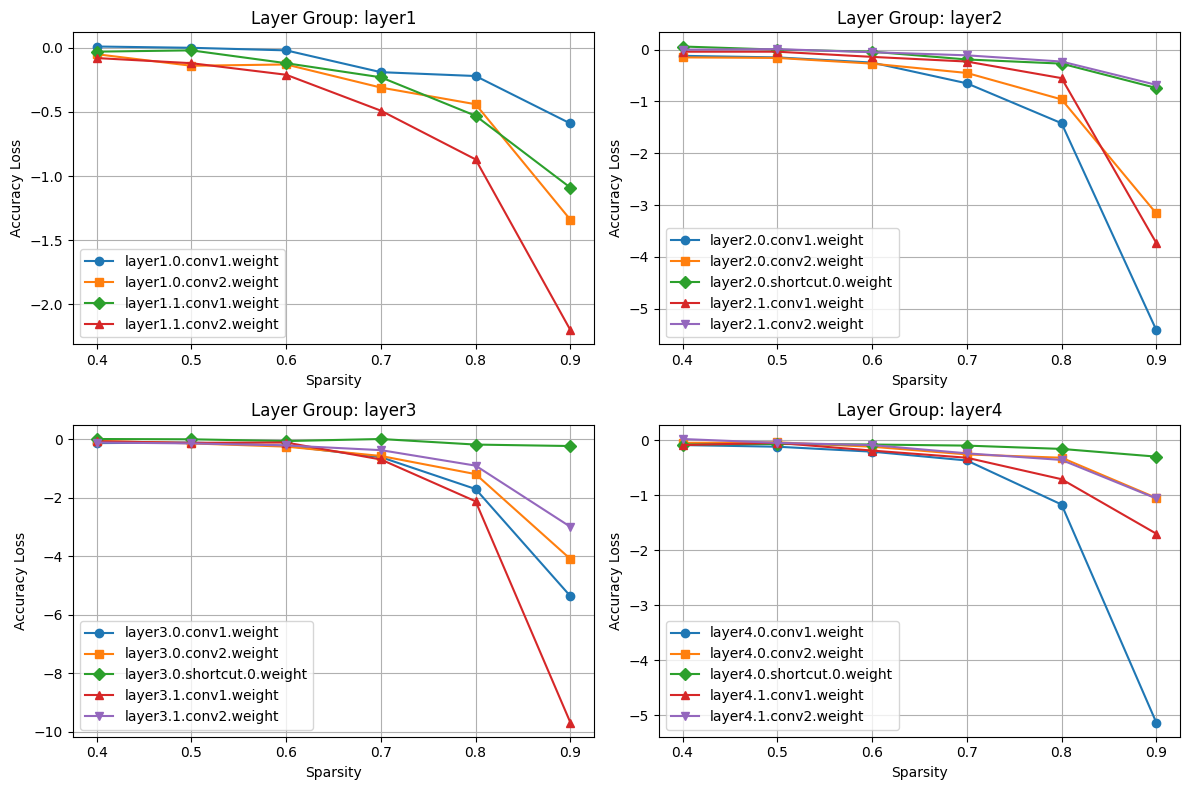

In [ ]:
plot_layer_sensitivity(layer_accuracies, sparsities)

## Layer-wise Adaptive Model Pruning

**Context & Motivation:**

As discussed earlier, we want a layer-wise sparsity level to optimize the magnitude pruning performance.

**Methods & Concepts:**

The primary logic for this task is to create a Per-Layer Sparsity Dictionary. This dictionary acts as a configuration map where each key is a layer identifier (layer name) and each value is its corresponding sparsity level.

In [ ]:
layer_dict = {
    'layer1.0.conv1.weight': 0.6,
    'layer1.0.conv2.weight': 0.4,
    'layer1.1.conv1.weight': 0.5,
    'layer1.1.conv2.weight': 0.4,

    'layer2.0.conv1.weight': 0.5,
    'layer2.0.conv2.weight': 0.4,
    'layer2.0.shortcut.0.weight': 0.6,
    'layer2.1.conv1.weight': 0.3,
    'layer2.1.conv2.weight': 0.6,

    'layer3.0.conv1.weight': 0.3,
    'layer3.0.conv2.weight': 0.5,
    'layer3.0.shortcut.0.weight': 0.7,
    'layer3.1.conv1.weight': 0.3,
    'layer3.1.conv2.weight': 0.6,

    'layer4.0.conv1.weight': 0.4,
    'layer4.0.conv2.weight': 0.5,
    'layer4.0.shortcut.0.weight': 0.7,
    'layer4.1.conv1.weight': 0.3,
    'layer4.1.conv2.weight': 0.7,
}

In [ ]:
recover_model()
print(f'Sparsity before pruning: {calculate_sparsity(model)}')

for name, param in model.named_parameters():
    if param.dim() > 1 and name in layer_dict:
        pruned_tensor, mask = magnitude_pruning(param, layer_dict[name])
        param.data.copy_(pruned_tensor)

acc = evaluate(model, dataloader['test'])
print()
print(f'after pruning: {calculate_sparsity(model):4f}, accuracy: {acc}%')


Recovering model to its original state.
Sparsity before pruning: 0.0



after pruning: 0.478186, acuracy: 93.42%


# Module 3: Regularization-Based Pruning

Regularization-based pruning leverages additional penalty terms in the loss function to encourage the network to automatically reduce the importance of certain weights. By applying L1 or L2 regularization, the optimization process naturally drives unimportant weights closer to zero, making them candidates for pruning.

<p align="center">
  <img src="https://github.com/shawnyin128/25Fall-CSCI-GA-3033-EfficientAI-Materials/raw/master/graph/regularization.png" alt="Magnitude Pruning" width="1000"/>
</p>

In this module, we will implement regularization-based pruning by adding L1 regularization or L2 regularization terms to the training loss, observe how regularization affect the sparsity pattern comparing with pure magnitude quantizaiton.

## L1 Regularization

**Context & Motivation:**

Unlike other methods, $L_1$ puts constant pressure on smaller weights, driving them to become exactly zero. This creates a more redundant weight distribution.

**Methods & Concepts:**

The core approach is to modify the loss function by adding an $L_1$ penalty term, defined as $L(w) + \lambda ||w||_1$. This term penalizes the absolute magnitude of the weights. During backpropagation, this constant pressure drives less important weights toward zero.

In [ ]:
from IPython.utils.py3compat import re
def l1_regularized_loss(model: torch.nn.Module, output: torch.Tensor, target: torch.Tensor, reg_lambda: float = 1e-5, device: str="cuda"):
  ce_loss = F.cross_entropy(output, target)

  regularization_loss = torch.tensor(0.0, device=device)
  for name, param in model.named_parameters():
    if param.dim() > 1 and 'layer' in name:
      regularization_loss += param.abs().sum()
      
  loss = ce_loss + reg_lambda * regularization_loss
  return loss

## L2 Regularization

**Context & Motivation:**

While $L_1$ regularization promotes exact sparsity by driving weights to zero, $L_2$ regularization aims to minimize the overall energy of the model by penalizing the square of the weights. By comparing $L_2$ with $L_1$, we can observe how different weight landscapes affect the model's sensitivity to subsequent pruning.

**Methods & Concepts:**

The core approach is to modify the loss function by adding an $L_2$ penalty term, defined as $L(w) + \lambda ||w||_2$. This term penalizes the absolute magnitude of the weights. During backpropagation, this constant pressure drives less important weights toward zero.

In [ ]:
def l2_regularized_loss(model: torch.nn.Module, output: torch.Tensor, target: torch.Tensor, reg_lambda: float = 1e-5, device: str="cuda"):
  ce_loss = F.cross_entropy(output, target)

  regularization_loss = torch.tensor(0.0, device=device)
  for name, param in model.named_parameters():
    if param.dim() > 1 and 'layer' in name:
      regularization_loss += torch.sqrt((param**2).sum())

  loss = ce_loss + reg_lambda * regularization_loss
  return loss

## Model Fine-tune

**Context & Motivation:**

Defining a loss function is only the first step; to actually modify the model’s weights, the loss must be integrated into a training loop. By embedding our regularized loss into the standard training flow, we enable the model to learn while simultaneously adhering to the structured constraints ($L_1$ or $L_2$) we have imposed.

**Methods & Concepts:**

A typical PyTorch training loop consists of five essential steps:

1.   **Forward**
2.   **Loss Computation**
3.   **Gradient Zeroing**
4.   **Backward**
5.   **Weight Update**

Our regularization-based loss function will affect the second step.



In [ ]:
def regularized_fine_tune(model: nn.Module,
                          dataloader: DataLoader,
                          loss_funciton: Callable,
                          device: str = 'cuda'):
    model.to(device)
    model.train()

    finetune_params = []
    for name, param in model.named_parameters():
        if param.dim() > 1 and 'layer' in name:
            param.requires_grad = True
            finetune_params.append(param)
        else:
            param.requires_grad = False
    optimizer = torch.optim.SGD(finetune_params, lr=1e-3)

    epochs = 10

    for epoch in range(epochs):
       with tqdm(total=len(dataloader), desc=f"Train Epoch {epoch+1}") as pbar:
            for batch_idx, (inputs, targets) in enumerate(dataloader):
                inputs, targets = inputs.to(device), targets.to(device)
                # 1) Forward
                outputs = model(inputs)

                # 2) Compute the loss
                loss = loss_funciton(model, outputs, targets, device=device)

                 # 3) Zero grads
                optimizer.zero_grad()

                # 4) Backward pass
                loss.backward()

                # 5) Update model parameters
                optimizer.step()

                pbar.update(1)
                pbar.set_postfix(loss=float(loss.item()))

    model.eval()

## Sensitivity Analysis

**Context & Motivation:**

After applying regularization, the model's weight distribution has been reshaped. To understand the practical impact of these changes, we need to re-evaluate the model's sensitivity to pruning. This comparison allows us to see if the regularization actually makes the model more robust to pruning.

**Methods & Concepts:**

We will reuse the sparsity analysis methodology established earlier. The core logic remains the same: we systematically increase the sparsity level and measure the resulting accuracy. The key difference here is the model—we are now analyzing a model that has undergone a training phase with a modified loss function ($L_1$ or $L_2$).

We will first run the L1 regularization fine-tuning. Run the next cell to apply fine-tune loop. This will take around 7 mins if you use T4 GPU.

In [ ]:
recover_model()
regularized_fine_tune(model, dataloader['train'], l1_regularized_loss)

Recovering model to its original state.


Train Epoch 10: 100%|██████████| 391/391 [00:10<00:00, 37.85it/s, loss=0.509]


Next, run the following sensitivity analysis first and try to understand how regularization-based method helps pruning.

In [ ]:
sparsities_reg, layer_accuracies_reg = sensitivity_scan_per_layer(model, dataloader['test'], 0.4, 0.1, 1.0)


Scanning layer: layer1.0.conv1.weight


Sparsity: 0.40 | Accuracy: 93.89%


Sparsity: 0.50 | Accuracy: 93.91%


Sparsity: 0.60 | Accuracy: 93.85%


Sparsity: 0.70 | Accuracy: 93.84%


...

Sparsity: 0.50 | Accuracy: 93.86%


Sparsity: 0.60 | Accuracy: 93.85%


Sparsity: 0.70 | Accuracy: 93.85%


Sparsity: 0.80 | Accuracy: 93.71%


Sparsity: 0.90 | Accuracy: 93.13%


Now, let's compare it with the previous sensitivity result. Run the following code to generate the accuracy comparison graph.

Here are some remarks for the graph:

**1. Each color represents a specific weight tensor.**

**2. Accuracy Difference is defined as:**

$$
\text{Accuracy Difference} = \text{Accuracy}_{\text{reg}} - \text{Accuracy}_{\text{mag}}
$$

where $\text{Accuracy}_{\text{reg}}$ is the accuracy (%) after pruning the L1-regularized model, and $\text{Accuracy}_{\text{mag}}$ is the accuracy (%) after applying magnitude pruning to the original model.

For example, if the accuracy difference is 0.7, it means that, at that sparsity level, the L1-regularized pruning result is 0.7 percentage points higher than the original magnitude-pruning accuracy.

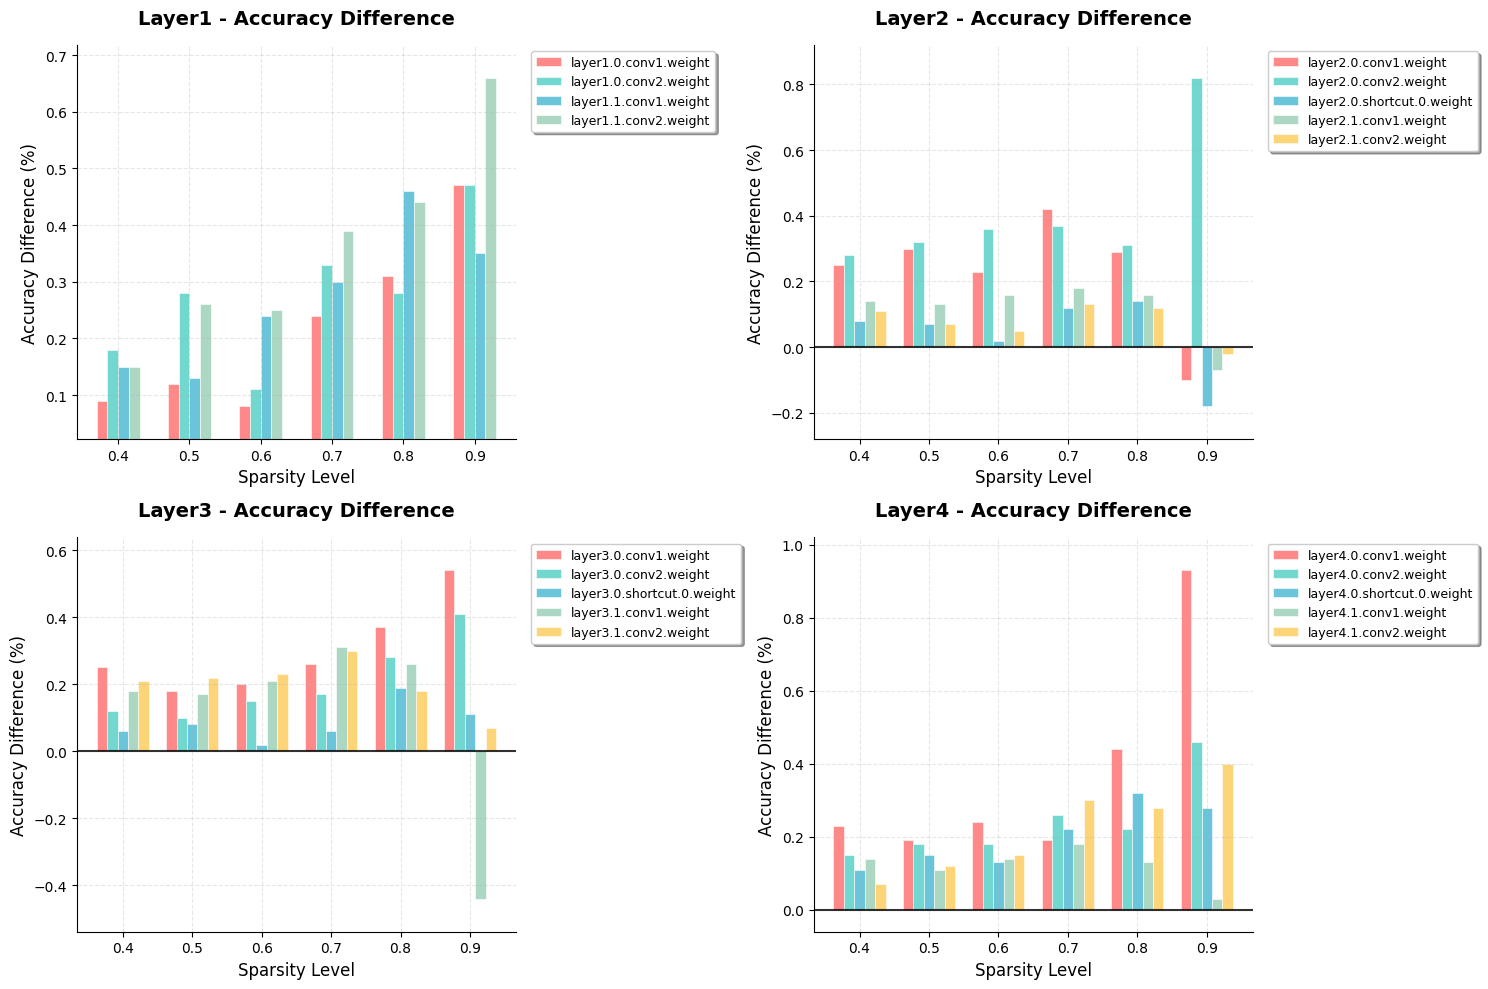

In [ ]:
plot_reg_model_accuracy_change(layer_accuracies, layer_accuracies_reg, sparsities_reg)

The process above illustrates the analysis for $L_1$ regularization. Next, we will follow the same logic, but with a different loss function, to analyze the impact of $L_2$ regularization on the model. Execute the following three cells to implement this process.

In [ ]:
recover_model()
regularized_fine_tune(model, dataloader['train'], l2_regularized_loss)

Recovering model to its original state.


Train Epoch 10: 100%|██████████| 391/391 [00:10<00:00, 38.59it/s, loss=0.0224]


In [ ]:
sparsities_reg, layer_accuracies_reg = sensitivity_scan_per_layer(model, dataloader['test'], 0.4, 0.1, 1.0)


Scanning layer: layer1.0.conv1.weight


Sparsity: 0.40 | Accuracy: 93.75%


Sparsity: 0.50 | Accuracy: 93.76%


Sparsity: 0.60 | Accuracy: 93.74%


Sparsity: 0.70 | Accuracy: 93.84%


...

Sparsity: 0.50 | Accuracy: 93.73%


Sparsity: 0.60 | Accuracy: 93.72%


Sparsity: 0.70 | Accuracy: 93.73%


Sparsity: 0.80 | Accuracy: 93.84%


Sparsity: 0.90 | Accuracy: 93.43%


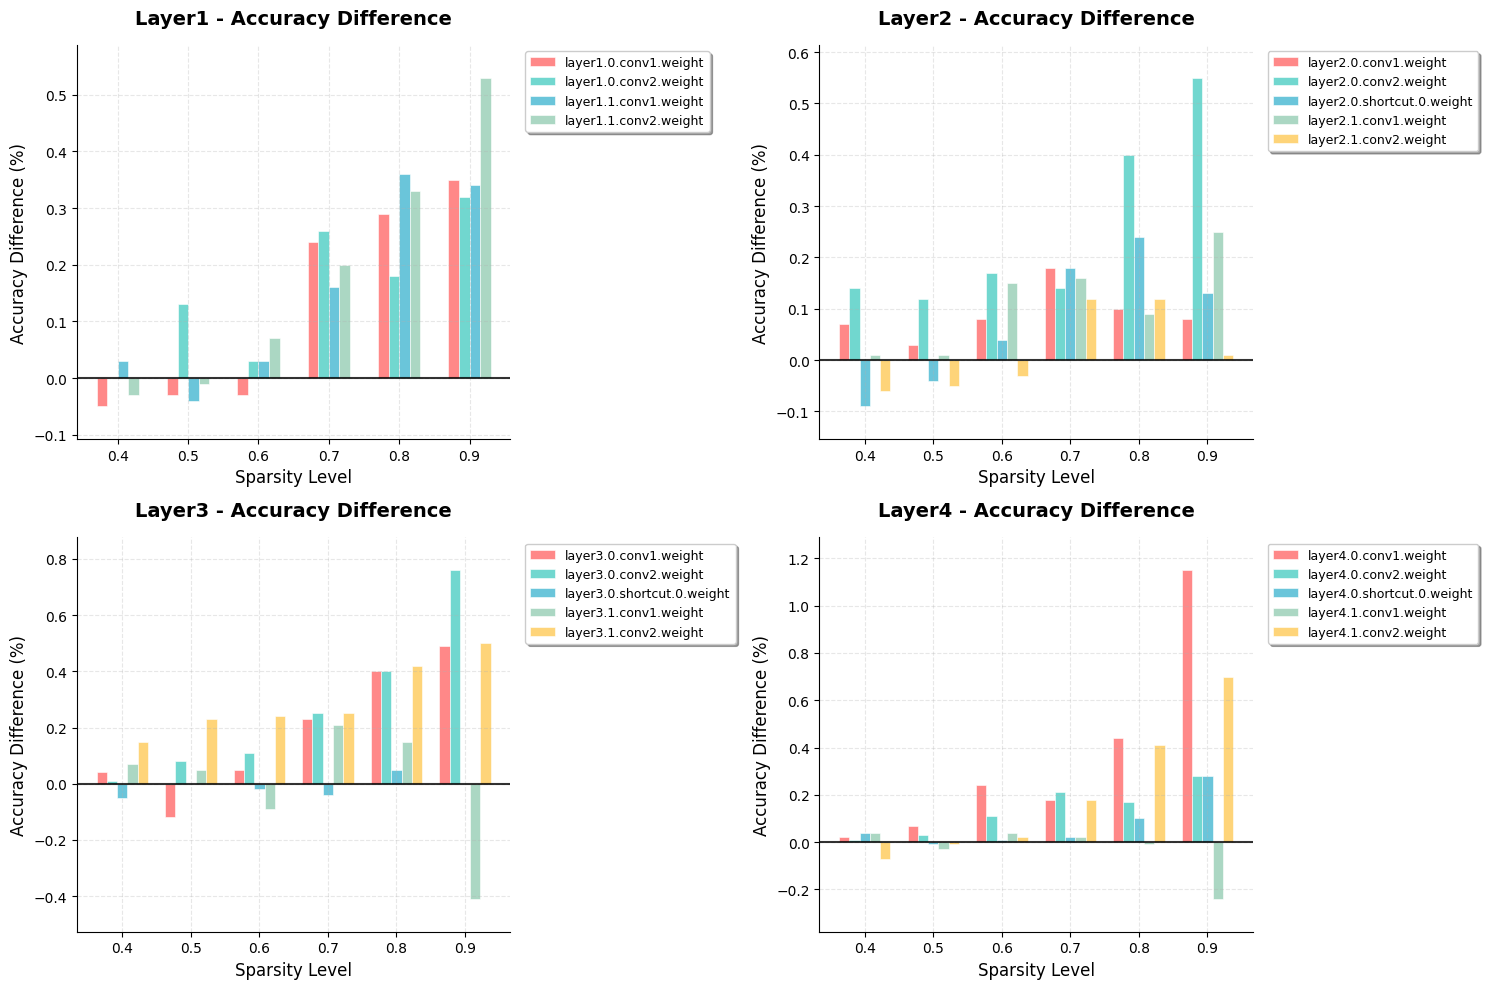

In [ ]:
plot_reg_model_accuracy_change(layer_accuracies, layer_accuracies_reg, sparsities_reg)

Based on the experimental results, which type of regularization performs better in most cases? How do the effects of L1 and L2 regularization on weight distribution differ? How do these distinct effects impact the final pruning performance?

**Answer:**

- L1 Regularization performs better in most cases, especially when the sparsity level is increased.

- Regarding how L1 and L2 change the weight distribution. L1 regularization pushes many small weights to 0 (or extremely near 0). It basically encourages sparsity during training, and its weight histograms would have a prominent peak at 0 with a heavier mass near zero. On the other hand, L2 regularization shrinks weights more smoothly/proportionally to magnitude. Unlike L1 regularization, L2 retains most of the weights in the model and does not push them to exactly zero, it just shrinks them. L2 regularization penalizes large weights much more than small ones because the penalty grows with $w^2$ (and the gradient is proportional to w), and as a result it mainly shrinks big weights while barely nudging tiny weights. So, the distribution gets “compressed” but doesn’t create a big pile-up at zero unlike L1. Therefore, its weight histogram becomes narrower around zero.

- This distinction would matter a lot for pruning performance, especially with magnitude pruning as we aim to remove the smallest |w|. What we care more about is how well the distribution separates important and unimportant weights. With L1, as mentioned in the previous point, the weight distributions would have a sharp peak at 0 with a population of near-zero weights. So, when we set a pruning threshold, we can successfully wipe out all these weights that were already contributing very little to the model's performance. So, we can achieve better accuracy at the same sparsity, and as sparsity increases, that advantage becomes even more pronounced, because the pruning threshold gets more aggressive and L1 has more “safe-to-remove” near-zero weights available before you start cutting into the weights that actually carry signal. On the other hand, with L2, you shrink everything, including moderately important weights. So, fewer weights are near zero and this shrinkage can often reduce the separation between “important” and “unimportant” magnitudes. As a result, when you prune by magnitude, you may start to cut weights that are important and still carry signal. Therefore, as sparsity increases, the accuracy tends to drop sooner.

# Module 4: Structured Pruning

In the previous part of our lab, we implemented and evaluated the performance of unstructured magnitude pruning. While unstructured pruning typically leads to better performance due to its finer granularity, it presents challenges in practical hardware implementations. This is because unstructured pruning can be difficult to optimize for, making it harder to achieve the theoretical improvements in efficiency.

<p align="center">
  <img src="https://github.com/shawnyin128/25Fall-CSCI-GA-3033-EfficientAI-Materials/raw/master/graph/structural.png" alt="structured Pruning" width="1000"/>

In this module, we will shift our focus to **Structured pruning**, specifically **filter** pruning. Structured pruning offers more direct benefits for hardware acceleration by removing entire filter, thus reducing the computational complexity in a manner that is easier to implement on modern hardware.


## Filter Pruning

**Context & Motivation:**


Logically, structured pruning is very similar to the magnitude pruning we implemented earlier; we still need a criterion to determine which parameters are important. However, the difference is that this criterion operates at the structured level (filters) rather than at a per-element level. Just as we used weight magnitude to identify redundant individual weights, we can apply a similar philosophy to filters to identify which entire 3D structures contribute the least to the model's feature extraction.

**Methods & Concepts:**

Our filter pruning strategy will be based on $L_1$ norm.

1. **L1 Norm Calculation for Each Filter**:

   For each weight filter \( $c_{out}$ \) in the convolutional layer, the L1 norm is computed as:

   $$
   L1(W_{c_{out}}) = \sum_{i=1}^{K} \sum_{j=1}^{K} \sum_{c_{in}=1}^{C_{in}} |W_{c_{out}}(i,j,c_{in})|
   $$

   Where:
   - $$ W_{c_{out}} \in \mathbb{R}^{K \times K \times C_{in}} \text{ is the weight of output filter }  c_{out} $$
   - $$ K \times K \text{ is the spatial size of the filter, and } C_{in} \text{ is the number of input channels} $$

2. **Pruning Based on L1 Norms**:

   After computing the L1 norm for each filter, the filters with the smaller L1 norms are pruned. Given a pruning ratio  p, the number of retained filters  C_retained is:

   $$
   C_{\text{retained}} = \left( 1 - p \right) \times C
   $$

   Where C  is the total number of weight filters.

3. **Filter Pruning Process**:

   The filters with the lower L1 norms are pruned, leaving only the top C_retained filters with the highest L1 norms.

   This pruning process ensures that only C_retained filters are kept.


In [ ]:
import torch
import torch.nn as nn
import copy

class ChannelPruner:
    def __init__(self, model: nn.Module, prune_ratio: float):
        """
        Initialize the pruner.

        Args:
            model (nn.Module): The model to be pruned.
            prune_ratio (float): The ratio of filters to prune (0.0 to 1.0).
        """
        self.model = copy.deepcopy(model)
        self.prune_ratio = prune_ratio

    def prune_conv_bn_layer(self, conv_layer: nn.Conv2d, bn_layer: nn.BatchNorm2d):
        """
        Prune a Conv2D layer and its corresponding BatchNorm2d layer based on the L1 norm.

        Args:
            conv_layer (nn.Conv2d): The Conv2D layer to prune.
            bn_layer (nn.BatchNorm2d): The BatchNorm2d layer corresponding to the Conv2D layer.

        Returns:
            mask (torch.Tensor): A boolean mask of the filters kept.
        """
        with torch.no_grad():
            out_channels = conv_layer.weight.shape[0]

            l1_norm = torch.abs(conv_layer.weight).sum(dim=(1, 2, 3))
            sorted_values, sorted_indices = torch.sort(l1_norm)

            prune_index = int(self.prune_ratio * out_channels)
            prune_index = min(max(prune_index, 0), out_channels)

            prune_indices = sorted_indices[:prune_index]

            mask = torch.ones_like(l1_norm, dtype=torch.bool)
            mask[prune_indices] = False
            conv_layer.weight.data[~mask, :, :, :] = 0

            if conv_layer.bias is not None:
              conv_layer.bias.data[~mask] = 0

            # Prune the BatchNorm2d layer in-place
            bn_layer.weight.data[prune_indices] = 0
            bn_layer.bias.data[prune_indices] = 0
            bn_layer.running_mean[prune_indices] = 0
            bn_layer.running_var[prune_indices] = 0


        return mask

    def prune_model(self):
        """
        Apply filter pruning to all Conv2D layers in the model and their corresponding BatchNorm2d layers.

        Returns:
            pruned_model (nn.Module): The pruned model.
        """
        previous_mask = None  # Mask from the previous layer
        shortcut_mask = None  # Mask for the shortcut connection
        idx = 1
        for name, layer in self.model.named_modules():
            if isinstance(layer, nn.Conv2d) and 'layer' in name:
                layer_idx = int(name.split('.')[0][-1])
                if layer_idx != idx:
                    idx = layer_idx
                    shortcut_mask = previous_mask
                # Get the corresponding BatchNorm2d layer
                if 'shortcut' not in name:
                    bn_layer_name = name.replace('conv', 'bn')
                else:
                    bn_layer_name = name.replace('shortcut.0', 'shortcut.1')
                    previous_mask = shortcut_mask

                bn_layer = dict(self.model.named_modules()).get(bn_layer_name, None)

                if bn_layer is not None:
                    # If there is a mask from the previous layer, apply it to the input channels
                    if previous_mask is not None:
                        # Ensure the mask is applied to the correct dimension of the weight tensor
                        # layer.weight = nn.Parameter(layer.weight[:, previous_mask, :, :])
                        layer.weight.data[:, ~previous_mask, :, :] = 0  # Set pruned input filters to zero


                    # Prune the current Conv2D and BatchNorm2D layers and get the new mask
                    mask = self.prune_conv_bn_layer(layer, bn_layer)

                    # Update the mask for the next layer (output channels -> next layer's input channels)
                    previous_mask = mask

        return self.model


Next, we will apply the structured pruning and check the pruned model accuracy.

In [ ]:
recover_model()
pruner = ChannelPruner(model, prune_ratio=0.1)
pruned_model = pruner.prune_model()

Recovering model to its original state.


In [ ]:
acc = evaluate(pruned_model, dataloader['test'])
print(f"\nAfter filter-prune, the accuracy is {acc}%")


After filter-prune, the accuracy is 88.83%


# Module 5: Iterative Pruning

In Module 4, we have implemented the filter-wise structral pruning strategy. The pruned model has a relative low sparsity level but a large degradation compared with magnitude pruning. A typical strategy to restore the accuracy is **Iterative Pruning**, within each iteration, two steps are involved:

*   Prune part of the weights
*   Retrain the remaining weight for accuracy recovery


Since we already know how to prune the model, in this Module, we will **dive into post-pruning retrain**.

## Generate Mask

**Context & Motivation:**

When we retrain a pruned model, the primary challenge is ensuring that the pruned weights remain at zero. Even if a weight is successfully pruned, the standard optimization process will calculate a non-zero gradient for that position during backpropagation. Without intervention, the optimizer will use these gradients to update the weights, causing the "pruned" values to become non-zero again and effectively destroying the model's sparsity.

**Methods & Concepts:**

To maintain the pruned structure, we implement a **masking mechanism** on the gradients. By applying a binary mask (where 0 represents a pruned position and 1 represents a retained position) to the calculated gradients, we manually zero out the update signals for all pruned parameters.

In [ ]:
def generate_mask(model: nn.Module, eps: float = 1e-9):
    masks = {}
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
          # 1) Extract weights
          weights = module.weight.data

          # 2) Filter-wise magnitude
          filter_sum = weights.abs().sum(dim=(1,2,3))

          # 3) Compute 1D Mask: 1 if > eps else 0
          mask = torch.zeros_like(filter_sum, dtype=torch.bool)
          mask = (filter_sum > eps)

          # 4) 4D mask for weights: (n, 1, 1, 1)
          weight_mask = mask.view(-1,1,1,1)

          # 6) Store weight mask
          masks[f"{name}.weight"] = weight_mask

          # 5/6) If bias exists, store same 1D mask
          if module.bias is not None:
            masks[f"{name}.bias"] = mask
            
        elif isinstance(module, nn.BatchNorm2d):
            bn_keep_mask = (torch.abs(module.weight.data) > eps).float()
            masks[f"{name}.weight"] = bn_keep_mask
            masks[f"{name}.bias"] = bn_keep_mask

    return masks

## Apply Mask to Parameter

**Context & Motivation:**

After generating a mask, we must ensure it is applied to both the model's parameters and their corresponding gradients in each training step. Without a mask, the model can still generate non-zero gradient to the pruned weight which will make the weight non-pruned.

**Methods & Concepts:**

We use a unified function to apply the binary mask ($M$) to a single parameter ($W$) and its gradient ($\nabla$). This ensures that the pruned positions remain zeroed out in both the forward and backward passes. The logic follows two fundamental operations:


*   Weight Masking: $W_{\text{pruned}} = W \odot M$ (Ensures the model remains sparse)
*   Gradient Masking: $\nabla_{\text{pruned}} = \nabla \odot M$ (Ensures pruned weights are not updated)



In [ ]:
def apply_mask(param: torch.Tensor, mask_tensor: torch.Tensor):
    with torch.no_grad():
        mask = mask_tensor.to(device=param.device, dtype=param.dtype)

        param.mul_(mask)

        if param.grad is not None:
          param.grad.mul_(mask)

## Retrain Pipeline

**Context & Motivation:**

We have already implemented the necessary masking utility functions. The remaining task is to integrate them into the training loop. Without applying the mask during optimization, pruned weights will receive gradients and become non-zero again, breaking sparsity. The mask must be enforced at each update step.

**Methods & Concepts:**

To solve this, we must explicitly integrate our generate_mask and apply_mask functions into the training pipeline. First, generate_mask is used to create a dictionary mapping layer name to their mask tensor. Then, we manually call apply_mask in the training loop to ensure that both the weights ($W$) and the gradients ($\nabla$) are restricted by this mask.

In [ ]:
def cross_entropy_loss(output: torch.Tensor, target: torch.Tensor):
  return F.cross_entropy(output, target)

def post_pruning_retrain(model: nn.Module,
                         dataloader: DataLoader,
                         loss_function: Callable,
                         device: str = 'cuda'):
    model.to(device)
    model.train()

    masks = None
    finetune_params = []
    masks = generate_mask(model)

    for name, param in model.named_parameters():
      if name in masks.keys():
        param.requires_grad = True
        finetune_params.append(param)
      else:
        param.requires_grad = False

    optimizer = torch.optim.SGD(finetune_params, lr=1e-3, momentum=0.0, weight_decay=0.0)
    epochs = 10

    for _ in tqdm(range(epochs), leave=False):
        for batch in dataloader:
            x, y = batch
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = loss_function(out, y)

            optimizer.zero_grad()
            loss.backward()

            for name, param in model.named_parameters():
              if name in masks.keys():
                apply_mask(param, masks[name])

            optimizer.step()

    model.eval()
    return model

Let's retrain the pruned model and evalute it.

In [ ]:
retrained_model = copy.deepcopy(pruned_model)
retrained_model = post_pruning_retrain(retrained_model, dataloader['train'], cross_entropy_loss)

In [ ]:
acc = evaluate(retrained_model, dataloader['test'])
print(f"\nAfter retrain, the accuracy is {acc}%")


After retrain, the accuracy is 93.82%
